# Q15 -- Bond Exposure to CDS Spread Changes (Credit DV01)
**SMM269 Fixed Income | UniCredit IT0005599110**

The credit DV01 measures the change in the risky bond value per 1 bp
widening of the UniCredit 5Y CDS spread.

**Theory (Risky Bonds):**

    Q(t, T) = exp(-h*T),   h = CDS / (1-R)
    V_D = V_RF - CVA
    CVA = (1-R) * N * sum_i  P(t,T_i) * [Q(T_{i-1}) - Q(T_i)]

Credit DV01 = [V_D(CDS+1bp) - V_D(CDS-1bp)] / 2  (central difference)


---
## Imports and constants

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

_here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
sys.path.insert(0, _here)

from fi_calendar import (
    load_target_holidays, modified_following, add_business_days,
    days_30_360, yearfrac_act_360, yearfrac_act_365,
)
from fi_curve  import load_curve, make_df_fn
from fi_bond   import (
    build_schedule, load_vol_surface, get_flat_vol, price_bond, accrued_interest,
    TRADE_DATE, SPOT_LAG, ISSUE_DATE, MATURITY_DATE,
    NOTIONAL, PARTICIPATION, CURRENT_COUPON_RATE, CURRENT_PERIOD_START,
    K_EFF_CAP, K_EFF_FLOOR,
)
from fi_credit import price_risky_bond, bond_credit_dv01, survival_prob

RECOVERY_RATE = 0.40

HOLIDAYS_FILE       = os.path.join(_here, "Holidays.xlsx")
TERM_STRUCTURE_FILE = os.path.join(_here, "Interp_term_structure.xlsx")
VOL_SURFACE_FILE    = os.path.join(_here, "Shifted_Black_vol_surface.xlsx")

print("Modules loaded: fi_calendar | fi_curve | fi_bond | fi_credit")


Modules loaded: fi_calendar | fi_curve | fi_bond | fi_credit


---
## Load data, price RF and risky bond, compute credit DV01

In [21]:
# Load market data
holidays    = load_target_holidays(HOLIDAYS_FILE)
curve       = load_curve(TERM_STRUCTURE_FILE)
vol_surface = load_vol_surface(VOL_SURFACE_FILE, "6M")
spot_date   = add_business_days(TRADE_DATE, SPOT_LAG, holidays)
schedule    = build_schedule(ISSUE_DATE, MATURITY_DATE, holidays)
df_fn       = make_df_fn(curve, spot_date)

mat_adj   = modified_following(MATURITY_DATE, holidays)
cap_mat_y = yearfrac_act_365(spot_date, mat_adj)
sigma_cap = get_flat_vol(vol_surface, cap_mat_y, K_EFF_CAP)
sigma_flr = get_flat_vol(vol_surface, cap_mat_y, K_EFF_FLOOR)

CDS_SPOT_BP = 38.78   # UniCredit 5Y EUR CDS, 05-Nov-2025, UNIC5YEUAM=R

# Risk-free price
rf_result = price_bond(
    df_fn=df_fn, holidays=holidays, schedule=schedule, spot_date=spot_date,
    sigma_cap=sigma_cap, sigma_flr=sigma_flr,
)
RF_GROSS = rf_result['gross_price']

# Risky price and CVA
risky_result = price_risky_bond(
    df_fn=df_fn, schedule=schedule, spot_date=spot_date, holidays=holidays,
    cds_bp=CDS_SPOT_BP, sigma_cap=sigma_cap, sigma_flr=sigma_flr,
    recovery=RECOVERY_RATE,
)
CVA_VAL     = risky_result['cva']
RISKY_GROSS = risky_result['risky_gross']
AI          = accrued_interest(TRADE_DATE, CURRENT_PERIOD_START, CURRENT_COUPON_RATE, NOTIONAL)
RISKY_CLEAN = RISKY_GROSS - AI

# Credit DV01 (central finite difference)
bond_cds_dv01 = bond_credit_dv01(
    df_fn=df_fn, schedule=schedule, spot_date=spot_date, holidays=holidays,
    cds_bp=CDS_SPOT_BP, sigma_cap=sigma_cap, sigma_flr=sigma_flr,
    recovery=RECOVERY_RATE,
)

pv_components = {
    "FRN (floating, RF)":  rf_result['pv_frn'],
    "Floor strip (RF)":    rf_result['pv_floor'],
    "Cap strip (RF)":      rf_result['pv_cap'],
    "ZCB notional (RF)":   rf_result['pv_notional'],
    "Bond RF Gross":       RF_GROSS,
    "CVA":                 CVA_VAL,
    "Bond Risky Gross":    RISKY_GROSS,
    "Accrued Interest":    AI,
    "Bond Risky Clean":    RISKY_CLEAN,
}

# RF cashflow schedule for cross-check and sensitivity charts
rf_cashflows = []
for p in schedule:
    pay_date, start_date = p['Payment Date'], p['Start Date']
    end_date, reset_date = p['End Date'],     p['Reset Date']
    if pay_date <= spot_date:
        continue
    T_i   = yearfrac_act_365(spot_date, pay_date)
    df_i  = df_fn(pay_date)
    alpha = days_30_360(start_date, end_date) / 360.0
    if reset_date < spot_date:
        cf = NOTIONAL * CURRENT_COUPON_RATE * alpha
    else:
        df_s = df_fn(start_date)
        fwa  = yearfrac_act_360(start_date, end_date)
        F    = (df_s / df_i - 1.0) / fwa
        cf   = NOTIONAL * PARTICIPATION * F * alpha
    rf_cashflows.append((T_i, cf))
T_mat = yearfrac_act_365(spot_date, mat_adj)
rf_cashflows.append((T_mat, NOTIONAL))

assert bond_cds_dv01 < 0, "bond_cds_dv01 must be negative"

print(f"CDS spot (trade date): {CDS_SPOT_BP:.2f} bp  (UNIC5YEUAM=R)")
print(f"Recovery rate:         {RECOVERY_RATE*100:.0f}%")
print()
print(f"RF Gross Price:        EUR {RF_GROSS:.4f}")
print(f"CVA:                   EUR {CVA_VAL:.4f}")
print(f"Risky Gross Price:     EUR {RISKY_GROSS:.4f}")
print(f"Accrued Interest:      EUR {AI:.4f}")
print(f"Risky Clean Price:     EUR {RISKY_CLEAN:.4f}")
print()
print(f"bond_cds_dv01:         EUR {bond_cds_dv01:.4f}/bp")


CDS spot (trade date): 38.78 bp  (UNIC5YEUAM=R)
Recovery rate:         40%

RF Gross Price:        EUR 1102.2711
CVA:                   EUR 29.2888
Risky Gross Price:     EUR 1072.9823
Accrued Interest:      EUR 4.7794
Risky Clean Price:     EUR 1068.2029

bond_cds_dv01:         EUR -0.7352/bp


---
## Cross-check: credit DV01 from flat-rate CVA formula

In [22]:
# Cross-check: reproduce the fi_credit CVA and DV01 using the flat-rate
# approximation. Uses the same formula as fi_credit.py:
#   CVA = (1-R) * N * sum_i DF_i * (Q(T_{i-1}) - Q(T_i))
# The notional N appears in every period, not the period cash flow.
rf_rate  = 0.025   # approximate flat RF discount rate
bump_bp  = 1.0

h_base   = (CDS_SPOT_BP           / 1e4) / (1 - RECOVERY_RATE)
h_bumped = ((CDS_SPOT_BP + bump_bp) / 1e4) / (1 - RECOVERY_RATE)
T_mat    = rf_cashflows[-1][0]

cva_base = cva_bumped = 0.0
Q_prev_b = Q_prev_u = 1.0

for T_i, CF_i in rf_cashflows:
    DF_i = np.exp(-rf_rate * T_i)
    Q_b  = np.exp(-h_base   * T_i)
    Q_u  = np.exp(-h_bumped * T_i)
    cva_base   += (1 - RECOVERY_RATE) * DF_i * NOTIONAL * (Q_prev_b - Q_b)
    cva_bumped += (1 - RECOVERY_RATE) * DF_i * NOTIONAL * (Q_prev_u - Q_u)
    Q_prev_b = Q_b; Q_prev_u = Q_u

dv01_approx = -(cva_bumped - cva_base) / bump_bp

cds_dv01_final = -abs(bond_cds_dv01)
print(f"Primary (fi_credit bump-and-reprice): EUR {cds_dv01_final:.4f}/bp")
print(f"Cross-check (flat-rate CVA formula):  EUR {dv01_approx:+.4f}/bp")
print(f"CVA (fi_credit):                      EUR {CVA_VAL:.4f}")
print(f"CVA (flat-rate approx):               EUR {cva_base:.4f}")


Primary (fi_credit bump-and-reprice): EUR -0.7352/bp
Cross-check (flat-rate CVA formula):  EUR -0.7307/bp
CVA (fi_credit):                      EUR 29.2888
CVA (flat-rate approx):               EUR 29.1290


---
## Sensitivity table: bond value vs CDS shifts

In [23]:
from datetime import timedelta

h_0 = (CDS_SPOT_BP / 1e4) / (1 - RECOVERY_RATE)

# Pre-compute (T_i, DF_i) pairs from the actual curve once
tf_cashflows = []
for T_i, CF_i in rf_cashflows:
    pay = spot_date + timedelta(days=int(round(T_i * 365.25)))
    tf_cashflows.append((T_i, df_fn(pay)))

rows = []
for bp_shift in [-50, -20, -10, -5, -1, +1, +5, +10, +20, +50, +100]:
    h_s = ((CDS_SPOT_BP + bp_shift) / 1e4) / (1 - RECOVERY_RATE)

    # Full reval: CVA at shifted CDS
    # CVA(h) = (1-R)*N * sum_i P(t,T_i) * (Q_{i-1}(h) - Q_i(h))
    cva_shifted = 0.0
    Q_prev = 1.0
    for T_i, DF_i in tf_cashflows:
        Q_i = np.exp(-h_s * T_i)
        cva_shifted += (1 - RECOVERY_RATE) * DF_i * NOTIONAL * (Q_prev - Q_i)
        Q_prev = Q_i

    dV_full   = (RF_GROSS - cva_shifted) - RISKY_GROSS
    dV_linear = cds_dv01_final * bp_shift
    rows.append({
        "ΔCDS (bp)":           f"{bp_shift:+d}",
        "ΔV linear (EUR)":     f"{dV_linear:+.2f}",
        "ΔV full reval (EUR)": f"{dV_full:+.2f}",
        "Error (EUR)":         f"{dV_full - dV_linear:+.2f}",
    })
display(pd.DataFrame(rows))
print("Error = full reval - linear. Non-zero error reflects credit convexity.")


,ΔCDS (bp),ΔV linear (EUR),ΔV full reval (EUR),Error (EUR)
0,-50,+36.76,+38.06,+1.30
1,-20,+14.70,+14.91,+0.21
2,-10,+7.35,+7.40,+0.05
3,-5,+3.68,+3.69,+0.01
4,-1,+0.74,+0.74,+0.00
5,+1,-0.74,-0.73,+0.00
6,+5,-3.68,-3.66,+0.02
7,+10,-7.35,-7.30,+0.05
8,+20,-14.70,-14.50,+0.20
9,+50,-36.76,-35.52,+1.24


Error = full reval - linear. Non-zero error reflects credit convexity.


---
## Figure: bond value and credit DV01 vs CDS spread

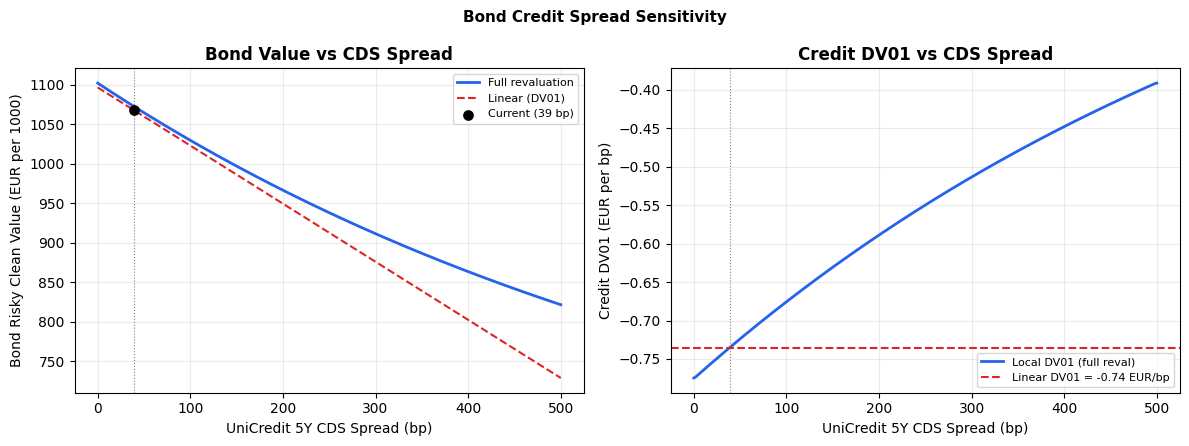

The credit DV01 curve slopes downward -- positive credit convexity.
Linear DV01 is a good approximation for moves within +/-20 bp.
For larger moves, full revaluation is needed.


In [26]:
cds_range = np.linspace(0, 500, 300)
V_RF      = pv_components["Bond RF Gross"]

# Full revaluation: CVA at each CDS level
# CVA(h) = (1-R)*N * sum_i P(t,T_i) * (Q_{i-1}(h) - Q_i(h))
# tf_cashflows = [(T_i, DF_i)] pre-computed in Cell 4 from the actual curve
V_risky = np.zeros(len(cds_range))
for k, cds in enumerate(cds_range):
    h = (cds / 1e4) / (1 - RECOVERY_RATE)
    cva = 0.0
    Q_prev = 1.0
    for T_i, DF_i in tf_cashflows:
        Q_i  = np.exp(-h * T_i)
        cva += (1 - RECOVERY_RATE) * DF_i * NOTIONAL * (Q_prev - Q_i)
        Q_prev = Q_i
    V_risky[k] = V_RF - cva

V_linear = pv_components["Bond Risky Clean"] + cds_dv01_final * (cds_range - CDS_SPOT_BP)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(cds_range, V_risky,  color="#2563EB", lw=2,       label="Full revaluation")
ax.plot(cds_range, V_linear, color="#DC2626", lw=1.5, ls="--", label="Linear (DV01)")
ax.axvline(CDS_SPOT_BP, color="gray", lw=0.8, ls=":")
ax.scatter([CDS_SPOT_BP], [pv_components["Bond Risky Clean"]],
           color="black", zorder=5, s=45, label=f"Current ({CDS_SPOT_BP:.0f} bp)")
ax.set_xlabel("UniCredit 5Y CDS Spread (bp)")
ax.set_ylabel("Bond Risky Clean Value (EUR per 1000)")
ax.set_title("Bond Value vs CDS Spread", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[1]
dv01_local = np.gradient(V_risky, cds_range[1] - cds_range[0])
ax.plot(cds_range, dv01_local, color="#2563EB", lw=2, label="Local DV01 (full reval)")
ax.axvline(CDS_SPOT_BP, color="gray", lw=0.8, ls=":")
ax.axhline(cds_dv01_final, color="#DC2626", lw=1.5, ls="--",
           label=f"Linear DV01 = {cds_dv01_final:.2f} EUR/bp")
ax.set_xlabel("UniCredit 5Y CDS Spread (bp)")
ax.set_ylabel("Credit DV01 (EUR per bp)")
ax.set_title("Credit DV01 vs CDS Spread", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

plt.suptitle("Bond Credit Spread Sensitivity", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_q15_credit_dv01.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("The credit DV01 curve slopes downward -- positive credit convexity.")
print("Linear DV01 is a good approximation for moves within +/-20 bp.")
print("For larger moves, full revaluation is needed.")
